# Contaminación lumínica en la Provincia de Buenos Aires
### Análisis exploratorio con datos satelitales VIIRS

[**StarMap BA**](https://starmapba.com.ar) rankea puntos de observación astronómica según la oscuridad del cielo. Los valores de **Bortle** de cada punto se asignaron a mano a partir de una grilla VIIRS gruesa (~5.5 km).

Este notebook usa el producto satelital de **alta resolución** (VNL v2.2, 463 m) para responder dos preguntas:

1. ¿Cómo se distribuye la contaminación lumínica en la Provincia?
2. **¿El satélite valida los ratings de Bortle de los 13 puntos?**

**Dato:** VIIRS VNL v2.2 anual 2024 (`median_masked`) — Earth Observation Group / NOAA, dominio público. Recortado a la Provincia con el polígono oficial IGN (mismo límite que usa la app).

In [1]:
%matplotlib inline
import json
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Puntos curados de la app (fuente de verdad) y raster recortado a BA
puntos = json.loads(Path("../data/seed-points.json").read_text("utf-8"))["puntos"]
df = pd.DataFrame(puntos)[["nombre", "partido", "lat", "lng", "distancia_caba_km", "tipo", "bortle", "sqm"]]

ds = rasterio.open("data/viirs_ba_2024.tif")
arr = ds.read(1).astype("float64")
print(f"Raster BA: {ds.width}x{ds.height} px | {ds.res[0]*111000:.0f} m/px | CRS {ds.crs}")
df.head()

Raster BA: 1614x1861 px | 463 m/px | CRS EPSG:4326


,nombre,partido,lat,lng,distancia_caba_km,tipo,bortle,sqm
0,Campo al sur de la Laguna de Lobos,Lobos,-35.280,-59.210,110,laguna,4,20.4
1,Campo al sur de Chascomús,Chascomús,-35.700,-58.160,140,pampa,3,21.3
2,Pipinas — Centro Espacial Punta Indio,Punta Indio,-35.536,-57.336,160,pampa,4,20.4
3,Vuelta de Obligado (San Pedro),San Pedro,-33.596,-59.817,175,pampa,4,20.4
4,Observatorio Cielos Albertinos (Alberti rural),Alberti,-35.100,-60.350,181,pampa,4,20.4


## 1. El dato satelital

El producto `median_masked` ya filtra ruido de fondo y luces efímeras: deja sólo la luz **persistente**. Veamos cuánto de la Provincia tiene luz detectable.

In [2]:
lit = arr[arr > 0]
pct_lit = 100 * lit.size / arr.size
print(f"Píxeles con luz detectable: {lit.size:,} de {arr.size:,} ({pct_lit:.1f}%)")
print(f"-> el {100 - pct_lit:.1f}% de la Provincia está bajo el umbral de detección: cielo oscuro")
print(f"Radiancia [nW/cm2/sr]:  mediana {np.median(lit):.2f} | media {lit.mean():.2f} | máx {lit.max():.0f} (AMBA)")

Píxeles con luz detectable: 165,750 de 3,003,654 (5.5%)
-> el 94.5% de la Provincia está bajo el umbral de detección: cielo oscuro
Radiancia [nW/cm2/sr]:  mediana 1.27 | media 9.46 | máx 682 (AMBA)


## 2. Mapa de contaminación lumínica

Cada píxel es radiancia (escala log, porque va de ~0.3 a >600). En cyan, los 13 puntos de StarMap BA.

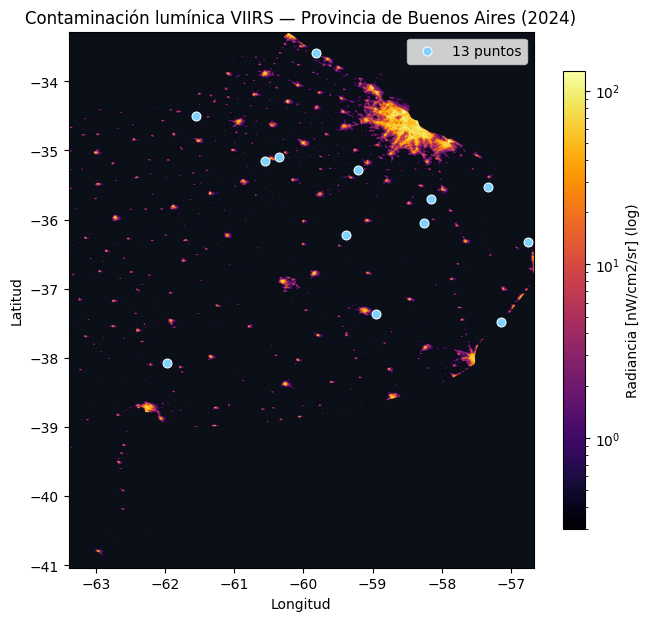

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 8.5))
ax.set_facecolor("#0b0f17")
disp = np.where(arr > 0, arr, np.nan)
b = ds.bounds
im = ax.imshow(disp, extent=[b.left, b.right, b.bottom, b.top], origin="upper",
               cmap="inferno", norm=LogNorm(vmin=0.3, vmax=float(np.nanpercentile(disp, 99.9))))
ax.scatter(df.lng, df.lat, c="#7fd4ff", s=42, edgecolor="white", linewidth=0.7, zorder=3, label="13 puntos")
ax.set(title="Contaminación lumínica VIIRS — Provincia de Buenos Aires (2024)",
       xlabel="Longitud", ylabel="Latitud")
plt.colorbar(im, ax=ax, label="Radiancia [nW/cm2/sr] (log)", shrink=0.7)
ax.legend(loc="upper right")
plt.show()

## 3. ¿El satélite valida los ratings de Bortle?

Muestreamos la radiancia en cada punto de dos formas:

- **`rad_punto`**: el píxel exacto (463 m).
- **`rad_3km`**: el promedio en un entorno de 3 km.

¿Por qué las dos? Porque las coordenadas de StarMap BA *apuntan a la celda oscura accesible* (lo dice la metadata del dato). Entonces el píxel exacto suele ser oscuro, pero el entorno captura el gradiente de luz del pueblo cercano — que es lo que define el Bortle del lugar.

In [4]:
def at_point(lat, lng):
    r, c = ds.index(lng, lat)
    return float(arr[r, c]) if (0 <= r < arr.shape[0] and 0 <= c < arr.shape[1]) else np.nan

def buffer_mean(lat, lng, km=3.0):
    deg = km / 111.0
    r0, c0 = ds.index(lng - deg, lat + deg)
    r1, c1 = ds.index(lng + deg, lat - deg)
    (r0, r1), (c0, c1) = sorted((r0, r1)), sorted((c0, c1))
    win = arr[max(0, r0):r1 + 1, max(0, c0):c1 + 1]
    return float(win.mean()) if win.size else np.nan

df["rad_punto"] = [at_point(p.lat, p.lng) for p in df.itertuples()]
df["rad_3km"] = [buffer_mean(p.lat, p.lng) for p in df.itertuples()]
df.sort_values("bortle")[["nombre", "partido", "bortle", "sqm", "rad_punto", "rad_3km"]].round(3)

,nombre,partido,bortle,sqm,rad_punto,rad_3km
7,Pampa profunda de Pila,Pila,2,21.6,0.000,0.000
5,"Yamay Ecoturismo (Pardo, Las Flores)",Las Flores,2,21.6,0.000,0.150
11,Faro Querandí (médanos costa atlántica),Villa Gesell,2,21.6,0.000,0.000
1,Campo al sur de Chascomús,Chascomús,3,21.3,0.000,0.000
12,Parque Provincial Tornquist (Sierra de la Vent...,Tornquist,3,21.3,0.000,0.027
2,Pipinas — Centro Espacial Punta Indio,Punta Indio,4,20.4,2.270,0.666
3,Vuelta de Obligado (San Pedro),San Pedro,4,20.4,4.371,0.281
0,Campo al sur de la Laguna de Lobos,Lobos,4,20.4,0.000,0.109
6,Pampa rural de Bragado,Bragado,4,20.4,0.000,0.053
4,Observatorio Cielos Albertinos (Alberti rural),Alberti,4,20.4,0.000,0.179


In [5]:
def spearman(a, b):
    return a.rank().corr(b.rank())  # Pearson sobre rangos = Spearman, sin scipy

print(f"Spearman Bortle vs radiancia (punto): {spearman(df.bortle, df.rad_punto):+.2f}")
print(f"Spearman Bortle vs radiancia (3 km):  {spearman(df.bortle, df.rad_3km):+.2f}  <- fuerte")
print(f"Spearman SQM    vs radiancia (3 km):  {spearman(df.sqm, df.rad_3km):+.2f}  (SQM alto = oscuro)")

Spearman Bortle vs radiancia (punto): +0.32
Spearman Bortle vs radiancia (3 km):  +0.76  <- fuerte
Spearman SQM    vs radiancia (3 km):  -0.76  (SQM alto = oscuro)


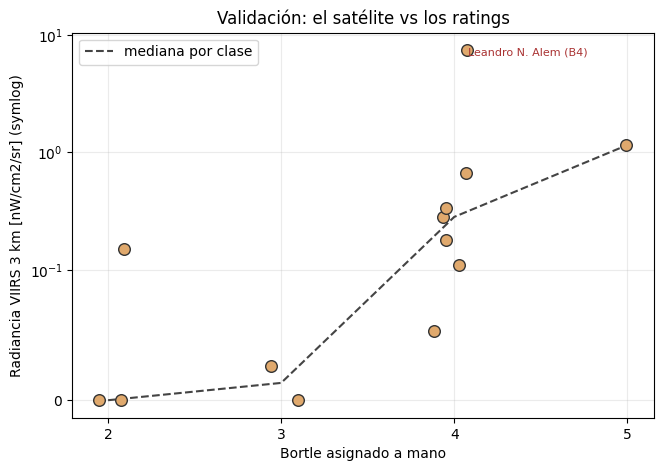

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5))
rng = np.random.default_rng(7)
ax.scatter(df.bortle + rng.uniform(-0.12, 0.12, len(df)), df.rad_3km,
           s=70, color="#e0a96d", edgecolor="#333", zorder=3)
med = df.groupby("bortle")["rad_3km"].median()
ax.plot(med.index, med.values, "--", color="#444", label="mediana por clase")
out = df.loc[df.rad_3km.idxmax()]
ax.annotate(f"{out.partido} (B{out.bortle})", (out.bortle, out.rad_3km),
            textcoords="offset points", xytext=(10, -4), fontsize=8, color="#a33")
ax.set_yscale("symlog", linthresh=0.1)
ax.set_xticks([2, 3, 4, 5])
ax.set(xlabel="Bortle asignado a mano", ylabel="Radiancia VIIRS 3 km [nW/cm2/sr] (symlog)",
       title="Validación: el satélite vs los ratings")
ax.legend(); ax.grid(True, alpha=0.25)
plt.show()

**Resultado: el satélite valida los ratings.** 🎯

- **Bortle vs radiancia (3 km): Spearman +0.76** — relación fuerte y monótona: más Bortle, más radiancia.
- **Bortle 2 y 3 → radiancia ≈ 0**: el satélite confirma que son cielos oscuros.
- El píxel exacto correlaciona poco (+0.32) pero el entorno de 3 km mucho (+0.76): esto **valida la metodología** de "coordenada en la celda oscura, lejos de la luz del pueblo".
- **Outlier honesto:** Vedia (*Leandro N. Alem*, Bortle 4) sale en 7.4 — bastante más brillante que los otros Bortle 4 (~0.3). Está a 2 km del pueblo: el satélite sugiere revisarlo, quizás está un escalón más urbano que B4.

## 4. Distribución de la radiancia

¿Cómo se reparte la luz entre los píxeles iluminados?

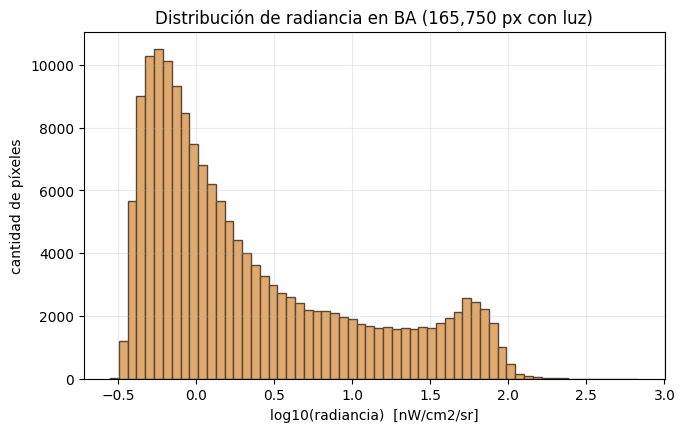

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(np.log10(lit), bins=60, color="#e0a96d", edgecolor="#5a4632")
ax.set(xlabel="log10(radiancia)  [nW/cm2/sr]", ylabel="cantidad de píxeles",
       title=f"Distribución de radiancia en BA ({lit.size:,} px con luz)")
ax.grid(True, alpha=0.25)
plt.show()

La distribución es **bimodal**: un pico grande de luz baja (pueblos y rutas rurales) y una joroba secundaria de luz alta (el AMBA y las ciudades). Entre medio, el gradiente periurbano.

## Conclusiones

- **El 94.5% de la Provincia está bajo el umbral de detección satelital**: hay muchísimo cielo oscuro accesible para astronomía.
- **Los ratings de Bortle de StarMap BA quedan validados** por un producto VIIRS independiente y de mayor resolución (Spearman +0.76).
- La metodología de "apuntar a la celda oscura accesible" se sostiene: los puntos caen en mínimos locales de radiancia.
- **A revisar:** el punto de Vedia, más brillante de lo esperado para Bortle 4.

**Próximos pasos:** calibrar un modelo radiancia→Bortle para pintar un mapa de Bortle de toda la Provincia, y usarlo para sugerir puntos nuevos en los mínimos de radiancia.

---
*Dato: VIIRS VNL v2.2 (EOG/NOAA, dominio público) · Análisis: Joaquin Rao para [StarMap BA](https://starmapba.com.ar)*